In [1]:
# import sys
# sys.path.append('..')

In [2]:
import os
import pickle
from collections import OrderedDict

import numpy as np
import pandas as pd
import scipy as sp

# import tensorflow as tf
# from tensorflow.keras import Model, Input, losses, layers, optimizers

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler

from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
import seaborn as sns

import itertools

from src.datasets import adults
# from src.models import vae_keras
# from src.datasets import adults#, dataset_utils

In [3]:
def binning_borders(series, nbin, drop_duplicates=True):
    """Returns a list of bin borders
    e.g. generates a list of 10 values for 9 bins (for [0,1])
    """
    
    bin_borders = [0]
    
    vals = np.sort(series.to_numpy())
    if drop_duplicates==True:
        vals = list(dict.fromkeys(vals)) # drop duplicates

    bin_depth = len(vals)/nbin
    for i in range(1, nbin):
        border_value = vals[int(i*bin_depth)]
        bin_borders.append(border_value)
    bin_borders.append(1.0)
    
    return bin_borders

def value_to_bin_index(x, bin_borders):
    """Returns the index of the bin a value belongs to
    e.g. a list with 10 binning borders consists of 9 bins/indices
    """
    for i in range(len(bin_borders)-1):
        if (x>=bin_borders[i] and x<bin_borders[i+1]):
            return i+1
    if x == 1.0:
        return 19
    if x < 0:
        return 0
    if x > 1.0:
        return 20
    raise Exception("value cannot belong to any bin", x, i, bin_borders, len(bin_borders))
    
def cramers_v_corrected(ftable):
    """Computes Cramer's V with bias correction
    to measure the correlation between two attributes.
    Input is a frequency table between 2 attributes.
    Returns Cramers V value € [0, 1]
    """
    n = np.sum(ftable)
    k, r = ftable.shape
    X2 = sp.stats.chi2_contingency(ftable)[0] # Pearson's chi-squared test statistic
    phi2 = X2 / n
    
    phitilde2 = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    ktilde = k - (k - 1)**2 / (n - 1)
    rtilde = r - (r - 1)**2 / (n - 1)

    V = np.sqrt(phitilde2 / min(ktilde - 1, rtilde - 1))
       
    return V

In [4]:
def TVD_ind(data_orig, data_synth, nbin=19, drop_duplicates=True):
    """ 
    Generates equal-depth bins based on the original data.
    Calculates the TVD between two one-dimensional distributions.
    Returns the 1 minus the average TVD over all marginals.
    """
    
    tvds = []
    
    # calculate TVDs for cont columns
    cols = data_synth.columns[:5]  # columns 0, 1, 2, 3, 4
    for col in cols:
        
        # discretize/bin based on original data
        bin_borders = binning_borders(data_orig[col], nbin, drop_duplicates)

        vals_orig = data_orig[col].to_numpy()
        vals_synth = data_synth[col].to_numpy()
        bin_counts_orig = []
        bin_counts_synth = []
        for i in range(nbin):
            
            col_bin_orig = [x for x in vals_orig if (x >= bin_borders[i] and x < bin_borders[i+1])]
            if i == (nbin-1):
                col_bin_orig = [x for x in vals_orig if (x >= bin_borders[i] and x <= bin_borders[i+1])]
            
            col_bin_synth = [x for x in vals_synth if (x >= bin_borders[i] and x < bin_borders[i+1])]
            if i == (nbin-1):
                col_bin_synth = [x for x in vals_synth if (x >= bin_borders[i] and x <= bin_borders[i+1])]            
            
            bin_counts_orig.append(len(col_bin_orig))
            bin_counts_synth.append(len(col_bin_synth))
            
        # add additional bins to each end of the range for synth data outside of range
        bin_counts_orig = [0] + bin_counts_orig + [0]
        bin_counts_synth = [len([x for x in vals_synth if x < bin_borders[0]])] + bin_counts_synth + [len([x for x in vals_synth if x > bin_borders[nbin]])]
            
        # calculate TVD for columns
        a = np.array(bin_counts_orig/np.sum(bin_counts_orig)).reshape(nbin+2,1)
        b = np.array(bin_counts_synth/np.sum(bin_counts_synth)).reshape(nbin+2,1)
        tvds.append(0.5 * sum(abs(a - b))[0])
        
    # # calculate TVDs for cat columns
    # for col in cat_cols:

    #     counts_orig_lst = []
    #     counts_synth_lst = []
        
    #     counts_orig = data_orig[col].value_counts(normalize=True)
    #     counts_synth = data_synth[col].value_counts(normalize=True)
        
    #     # align counts and treat non-occuring cat values in synth data
    #     for index, value in counts_orig.items():
    #         counts_orig_lst.append(value)
    #         if index in counts_synth:
    #             counts_synth_lst.append(counts_synth[index])
    #         else:
    #             counts_synth_lst.append(0)
                
    #     # calculate TVD for column
    #     a = np.array(counts_orig_lst).reshape(-1,1)
    #     b = np.array(counts_synth_lst).reshape(-1,1)
    #     tvds.append(0.5 * sum(abs(a - b))[0]) 
                
    print('\n1-TVD (Ind)')
    print(1-np.average(tvds))
    return 1-np.average(tvds)

In [5]:
def TVD_pair(data_orig, data_synth, nbin=19, drop_duplicates=True):
    """
    Generates equal-depth bins based on the original data.
    Calculates the TVD for each two-way marginal.
    Returns the 1 minus the average TVD over all marginals.
    """
    
    tvds = []
        
    data_o = data_orig.copy()
    data_s = data_synth.copy()
    
    # discretize cont cols
    cols = data_synth.columns[:5]  # columns 0, 1, 2, 3, 4
    for col in cols:
               
        # bin based on original data
        bin_borders = binning_borders(data_o[col], nbin, drop_duplicates)
        data_o[col] = data_o[col].apply(value_to_bin_index, bin_borders=bin_borders)
        data_s[col] = data_s[col].apply(value_to_bin_index, bin_borders=bin_borders)
        
        # bin counts
        counts_orig = data_o[col].value_counts(normalize=False)
        counts_synth = data_s[col].value_counts(normalize=False)
        
    for i in range(len(cols)-1):
        for j in range(i+1, len(cols)):
            
            marginals1 = pd.crosstab(data_o[cols[i]], data_o[cols[j]], margins=False, normalize=True)
            marginals2 = pd.crosstab(data_s[cols[i]], data_s[cols[j]], margins=False, normalize=True)
            
            marginals_subtracted = marginals1.subtract(marginals2)
            
            # drop NaNs which occur when subtraction includes value counts of 0 (e.g.  Holand-Netherlands 1 )
            marginals_subtracted = marginals_subtracted.dropna(axis=1, how='all')
            marginals_subtracted = marginals_subtracted.dropna(axis=0, how='all')

            
            tvds.append(0.5*marginals_subtracted.abs().to_numpy().sum())
    
    print('\n1-TVD (Pair)')
    print(1-np.average(tvds))
    return 1-np.average(tvds)

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np

def XGBoost_classifier_F1(data_orig, data_synth):
    def get_scale_pos_weight(y):
        """Helper to compute scale_pos_weight for XGBoost"""
        counts = np.bincount(y.astype(int))
        if len(counts) == 2 and counts[1] > 0:
            return counts[0] / counts[1]
        return 1

    print("\n=== Original Data Performance ===")
    # Split original data (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        data_orig.iloc[:, :-1],
        data_orig.iloc[:, -1],
        test_size=0.3,
        random_state=42,
        stratify=data_orig.iloc[:, -1]
    )

    scale_pos_weight_orig = get_scale_pos_weight(y_train)
    model = XGBClassifier(scale_pos_weight=scale_pos_weight_orig, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Accuracy: %.2f%%" % (accuracy_score(y_test, y_pred) * 100))
    print("F1: %.2f%%" % (f1_score(y_test, y_pred, average='binary') * 100))
    print("Classification report:\n", classification_report(y_test, y_pred))

    print("\n=== Synthetic Data Performance ===")

    # Upsample minority class in synthetic data
    df_majority = data_synth[data_synth.iloc[:, -1] == 0]
    df_minority = data_synth[data_synth.iloc[:, -1] == 1]

    if len(df_minority) > 0 and len(df_majority) > len(df_minority):
        df_minority_upsampled = resample(
            df_minority,
            replace=True,
            n_samples=len(df_majority),
            random_state=42
        )
        data_synth_balanced = pd.concat([df_majority, df_minority_upsampled])
    else:
        data_synth_balanced = data_synth.copy()

    # Prepare train/test sets
    X_train = data_synth_balanced.iloc[:, :-1]
    y_train = data_synth_balanced.iloc[:, -1]

    X_test = data_orig.iloc[:, :-1]
    y_test = data_orig.iloc[:, -1]

    scale_pos_weight_synth = get_scale_pos_weight(y_train)
    model = XGBClassifier(scale_pos_weight=scale_pos_weight_synth, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Unique predictions:", np.unique(y_pred))
    print("Accuracy: %.2f%%" % (accuracy_score(y_test, y_pred) * 100))
    print("F1: %.2f%%" % (f1_score(y_test, y_pred, average='binary') * 100))
    print("Classification report:\n", classification_report(y_test, y_pred))


    # if grid_search is not None:
    #     """
    #     Does the same as above, but peforms grid search to optimize
    #     number of estimators.
    #     """

    #     ### train on and classify original data
    #     print("\nOriginal data F1 macro score:")
    #     X_train = data_orig.iloc[:, 0:-1]
    #     y_train = data_orig.iloc[:, -1]

    #     X_test = X_train
    #     y_test = y_train

    #     # run with numeric categorical features
    #     for i in [50,100,200,400,800,1600]:

    #         # fit model no training data
    #         xgb_model = XGBClassifier(n_estimators=i,
    #                                   learning_rate=0.05,
    #                                   early_stopping_rounds=i-i*.75).fit(X_train,
    #                                                                   y_train,
    #                                                                   eval_set=[(X_test,y_test)],
    #                                                                   verbose=False)

    #         # make predictions for test data
    #         y_pred = xgb_model.predict(X_test)
    #         predictions = [round(value) for value in y_pred]

    #         # evaluate predictions
    #         accuracy = accuracy_score(y_test, predictions)
    #         print("Accuracy: %.2f%% --- %.2f N_estimators" % (accuracy * 100.0, i))
    #         f1 = f1_score(y_test, predictions, average='weighted') *100
    #         print("F1: %.2f%%" % (f1))


    #     ### train on synthetic data and classify original data
    #     print("\nSynthetic data F1 macro score:")
    #     X_train = data_synth.iloc[:, 0:-1]
    #     y_train = data_synth.iloc[:, -1]

    #     X_test = data_orig.iloc[:, 0:-1]
    #     y_test = data_orig.iloc[:, -1]

    #     # run with numeric categorical features
    #     for i in [50,100,200,400,800,1600]:

    #         # fit model no training data
    #         xgb_model = XGBClassifier(n_estimators=i,
    #                                   learning_rate=0.05,
    #                                   early_stopping_rounds=i-i*.75).fit(X_train,
    #                                                                   y_train,
    #                                                                   eval_set=[(X_test,y_test)],
    #                                                                   verbose=False)
    #         # make predictions for test data
    #         y_pred = xgb_model.predict(X_test)
    #         predictions = [round(value) for value in y_pred]

    #         # evaluate predictions
    #         accuracy = accuracy_score(y_test, predictions)
    #         print("Accuracy: %.2f%% --- %.2f N_estimators" % (accuracy * 100.0, i))
    #         f1 = f1_score(y_test, predictions, average='weighted') *100
    #         print("F1: %.2f%%" % (f1))

In [11]:
def evaluate_synthetic_data(data_orig, data_synth, metrics):
    """
    Takes an original dataset and a synthetic dataset generated from
    an algorithm that is trained on the former.
    Continuous values must be normalized.
    Categorical values must be mapped to numerical features.
    
    Returns 3 statistical metrics including:
    - average 1-TVD over all one-way marginals
    - average 1-TVD oder all two-way marginals
    - correlation accuracy (fraction of pairs of same correlation level)
    
    Returns the classification accuracy (F1 score using macro average) 
    of an XGBoost classifier trained on the synthetic data, used to
    make predictions on the original data.
    """

    # Statistical metrics
    if metrics[0]:
        ind = TVD_ind(data_orig, data_synth)
    if metrics[1]:
        pair = TVD_pair(data_orig, data_synth)
    # # Classification accuracy
    # if metrics[2]:
    #     XGBoost_classifier_F1(data_orig, data_synth)

    return ind, pair
    
# Load wilt original data for test purposes
# all_data, enc_dict, dec_dict, Scaler, cont_cols, cat_cols = adults.load_adults_data()
x_num_train = np.load('../data/wilt/X_num_train.npy', allow_pickle=True)
y_train = np.load('../data/wilt/y_train.npy', allow_pickle=True).reshape(-1,1)
data_train = np.concatenate([x_num_train, y_train], axis=1)

x_num_test = np.load('../data/wilt/X_num_test.npy', allow_pickle=True)
y_test = np.load('../data/wilt/y_test.npy', allow_pickle=True).reshape(-1,1)
data_test = np.concatenate([x_num_test, y_test], axis=1)

x_num_val = np.load('../data/wilt/X_num_val.npy', allow_pickle=True)
y_val = np.load('../data/wilt/y_val.npy', allow_pickle=True).reshape(-1,1)
data_val = np.concatenate([x_num_val, y_val], axis=1)

data_orig = np.concatenate((data_train, data_test, data_val), axis=0)
data_orig = pd.DataFrame(data_orig)

cols_to_normalize = data_orig.columns[:5]  # columns 0, 1, 2, 3, 4
scaler = MinMaxScaler()
data_orig[cols_to_normalize] = scaler.fit_transform(data_orig[cols_to_normalize])

# Load wilt synthetic data for test purposes
x_num_train = np.load('../exp/wilt/ddpm_cb_best/X_num_train.npy', allow_pickle=True)
y_train = np.load('../exp/wilt/ddpm_cb_best/y_train.npy', allow_pickle=True).reshape(-1,1)
# x_num_train = np.load('../exp/wilt/wilt_dp_eps_10_best/X_num_train.npy', allow_pickle=True)
# y_train = np.load('../exp/wilt/wilt_dp_eps_10_best/y_train.npy', allow_pickle=True).reshape(-1,1)

data_synth = np.concatenate([x_num_train, y_train], axis=1)
data_synth = pd.DataFrame(data_synth)

print(data_synth.shape)

cols_to_normalize = data_synth.columns[:5]  # columns 0, 1, 2, 3, 4
scaler = MinMaxScaler()
data_synth[cols_to_normalize] = scaler.fit_transform(data_synth[cols_to_normalize])

# run the first two statistical metrics:
print("\nrun the first statistical metrics:")
evaluate_synthetic_data(data_orig, data_synth, [1,1])



(24800, 6)

run the first statistical metrics:

1-TVD (Ind)
0.7475084761580971

1-TVD (Pair)
0.5164924529528229


(0.7475084761580971, 0.5164924529528229)

In [8]:
def get_tvds(eps_vals, data_orig):

    tvds_inds = []
    tvds_pairs = []
    
    for eps in eps_vals:
        x_num_train = np.load('../exp/wilt/wilt_dp_eps_' + str(eps) + '_best/X_num_train.npy', allow_pickle=True)
        y_train = np.load('../exp/wilt/wilt_dp_eps_' + str(eps) + '_best/y_train.npy', allow_pickle=True).reshape(-1,1)
        data_synth = np.concatenate([x_num_train, y_train], axis=1)
        data_synth = pd.DataFrame(data_synth)
        cols_to_normalize = data_synth.columns[:5]  # columns 0, 1, 2, 3, 4
        scaler = MinMaxScaler()
        data_synth[cols_to_normalize] = scaler.fit_transform(data_synth[cols_to_normalize])

        tvds_inds.append(TVD_ind(data_orig, data_synth))
        tvds_pairs.append(TVD_pair(data_orig, data_synth))
        
        
    return tvds_inds, tvds_pairs



# Load wilt original data for test purposes
# all_data, enc_dict, dec_dict, Scaler, cont_cols, cat_cols = adults.load_adults_data()
x_num_train = np.load('../data/wilt/X_num_train.npy', allow_pickle=True)
y_train = np.load('../data/wilt/y_train.npy', allow_pickle=True).reshape(-1,1)
data_train = np.concatenate([x_num_train, y_train], axis=1)

x_num_test = np.load('../data/wilt/X_num_test.npy', allow_pickle=True)
y_test = np.load('../data/wilt/y_test.npy', allow_pickle=True).reshape(-1,1)
data_test = np.concatenate([x_num_test, y_test], axis=1)

x_num_val = np.load('../data/wilt/X_num_val.npy', allow_pickle=True)
y_val = np.load('../data/wilt/y_val.npy', allow_pickle=True).reshape(-1,1)
data_val = np.concatenate([x_num_val, y_val], axis=1)

data_orig = np.concatenate((data_train, data_test, data_val), axis=0)
data_orig = pd.DataFrame(data_orig)

cols_to_normalize = data_orig.columns[:5]  # columns 0, 1, 2, 3, 4
scaler = MinMaxScaler()
data_orig[cols_to_normalize] = scaler.fit_transform(data_orig[cols_to_normalize])

eps_vals = [2, 3, 4, 5, 6, 7, 8, 9, 10]
# eps_vals = [10]

tvds_ind, tvds_pair = get_tvds(eps_vals, data_orig)

print(tvds_ind)
print(tvds_pair)




1-TVD (Ind)
0.1326839272976954

1-TVD (Pair)
0.06756314704451061

1-TVD (Ind)
0.20469406335619866

1-TVD (Pair)
0.12851286672799633

1-TVD (Ind)
0.27018599884006955

1-TVD (Pair)
0.19899535361211673

1-TVD (Ind)
0.3246921001406582

1-TVD (Pair)
0.2265931952416188

1-TVD (Ind)
0.29815374077555346

1-TVD (Pair)
0.2252644832976689

1-TVD (Ind)
0.4822727453019485

1-TVD (Pair)
0.3223665188422029

1-TVD (Ind)
0.4328999601109206

1-TVD (Pair)
0.28988415346242014

1-TVD (Ind)
0.3638311601303922

1-TVD (Pair)
0.2700099860675026

1-TVD (Ind)
0.450377584011626

1-TVD (Pair)
0.2993402787499416
[0.1326839272976954, 0.20469406335619866, 0.27018599884006955, 0.3246921001406582, 0.29815374077555346, 0.4822727453019485, 0.4328999601109206, 0.3638311601303922, 0.450377584011626]
[0.06756314704451061, 0.12851286672799633, 0.19899535361211673, 0.2265931952416188, 0.2252644832976689, 0.3223665188422029, 0.28988415346242014, 0.2700099860675026, 0.2993402787499416]


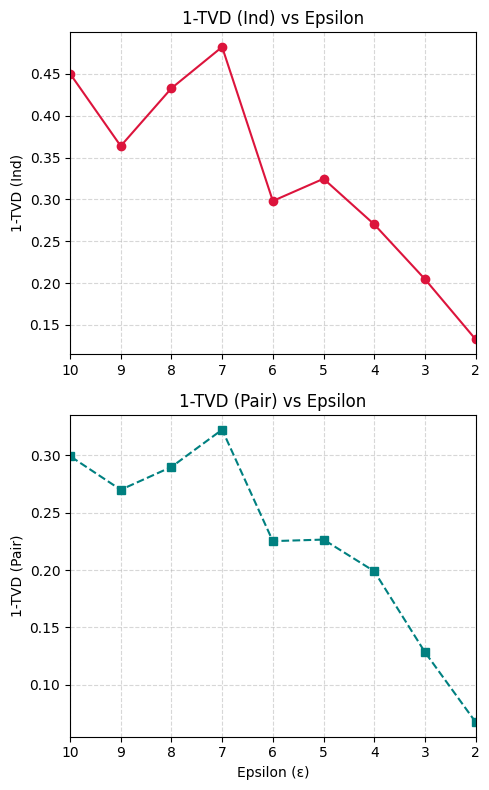

In [14]:
eps = [2, 3, 4, 5, 6, 7, 8, 9, 10]

tvds_ind = [0.1326839272976954, 0.20469406335619866, 0.27018599884006955, 0.3246921001406582, 0.29815374077555346, 0.4822727453019485, 0.4328999601109206, 0.3638311601303922, 0.450377584011626]
tvds_pair = [0.06756314704451061, 0.12851286672799633, 0.19899535361211673, 0.2265931952416188, 0.2252644832976689, 0.3223665188422029, 0.28988415346242014, 0.2700099860675026, 0.2993402787499416]


# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8))

# --- F1 Plot ---
ax1.plot(eps, tvds_ind, 'o-', color='crimson')
ax2.set_xlabel("Epsilon (ε)")
ax1.set_ylabel("1-TVD (Ind)")
ax1.set_title("1-TVD (Ind) vs Epsilon")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Noise Plot ---
ax2.plot(eps, tvds_pair, 's--', color='teal')
ax2.set_xlabel("Epsilon (ε)")
ax2.set_ylabel("1-TVD (Pair)")
ax2.set_title("1-TVD (Pair) vs Epsilon")
ax2.grid(True, linestyle="--", alpha=0.5)

# Invert x-axis so that 10 is left and 2 is right
ax1.set_xlim(10, 2)
ax2.set_xlim(10, 2)

plt.tight_layout()
plt.show()
